# CNN FUNDAMENTALS
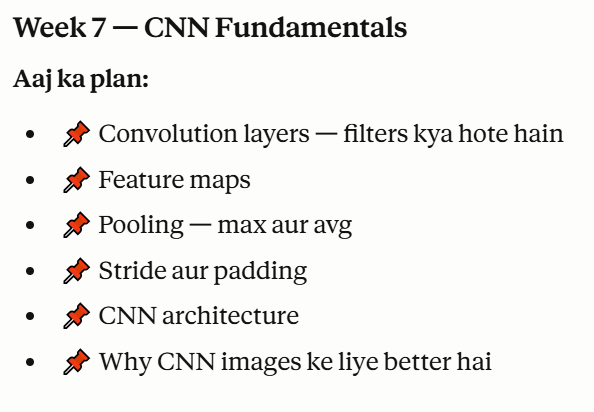

# CNN kya hota hai
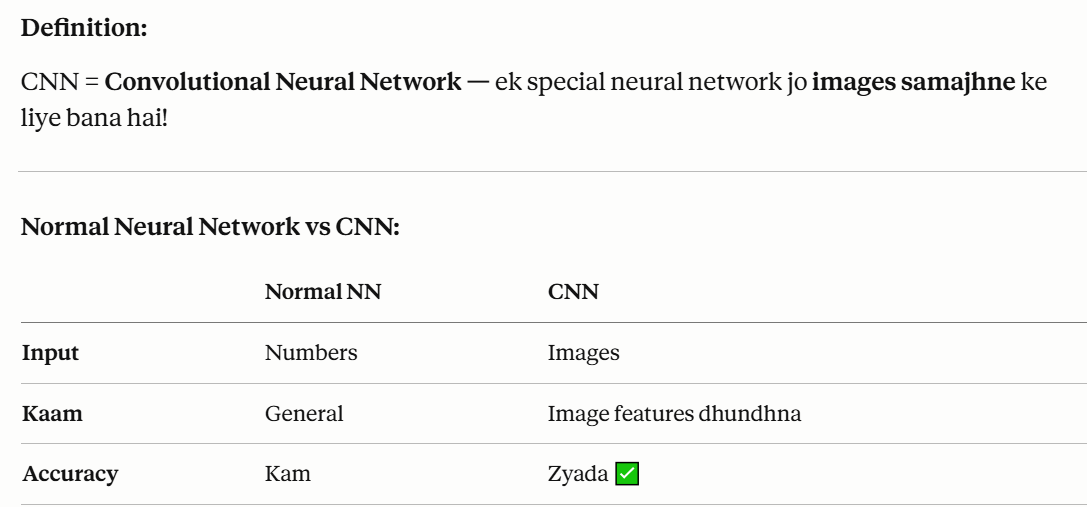

# Convolution Layer aur Filters kya hote hain?
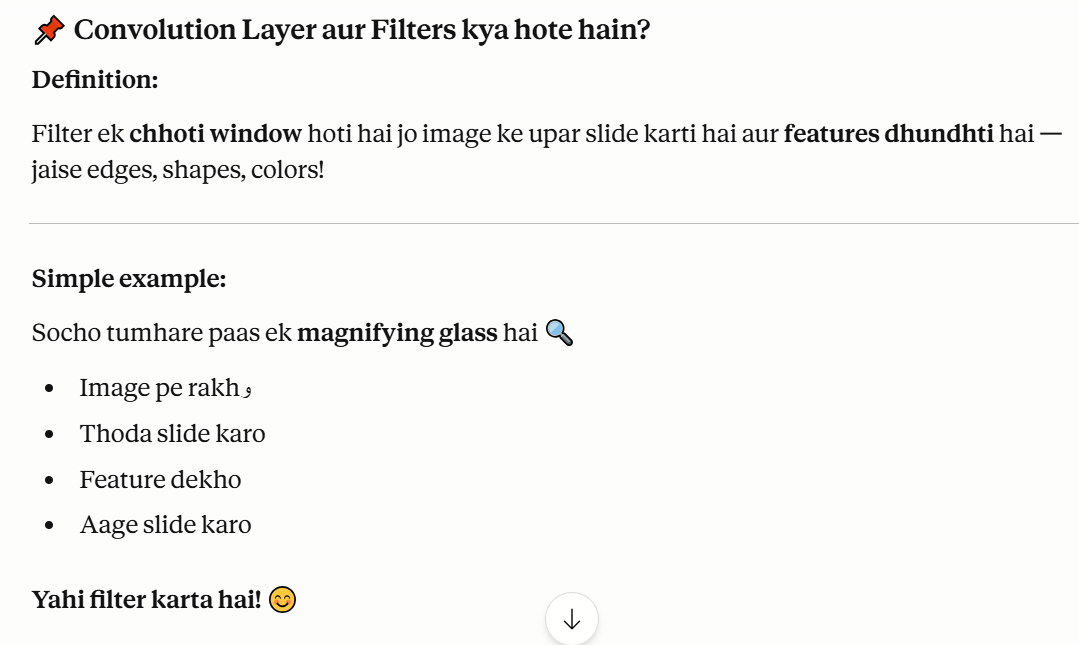
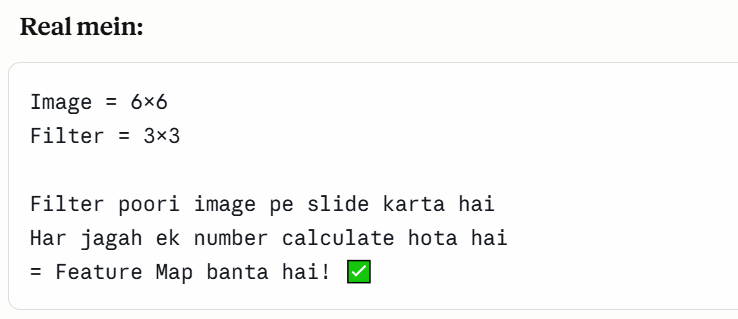
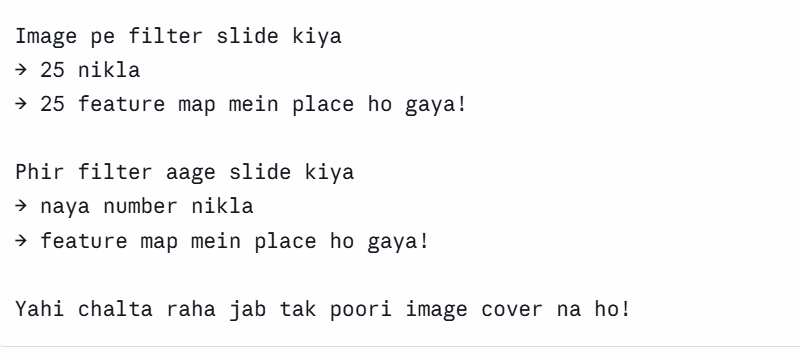

# Feature Map kya hota hai?
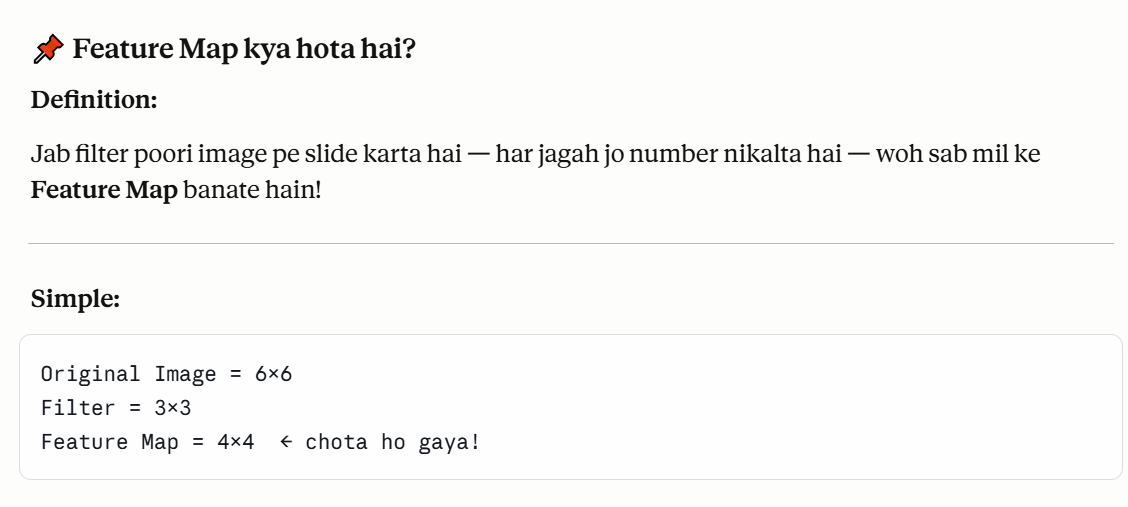

#  Pooling kya hota hai
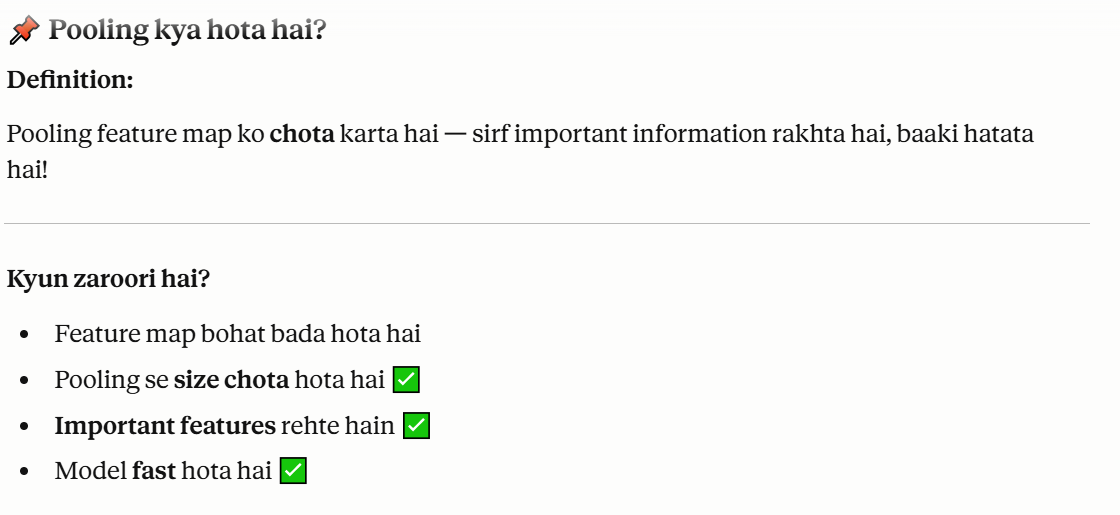
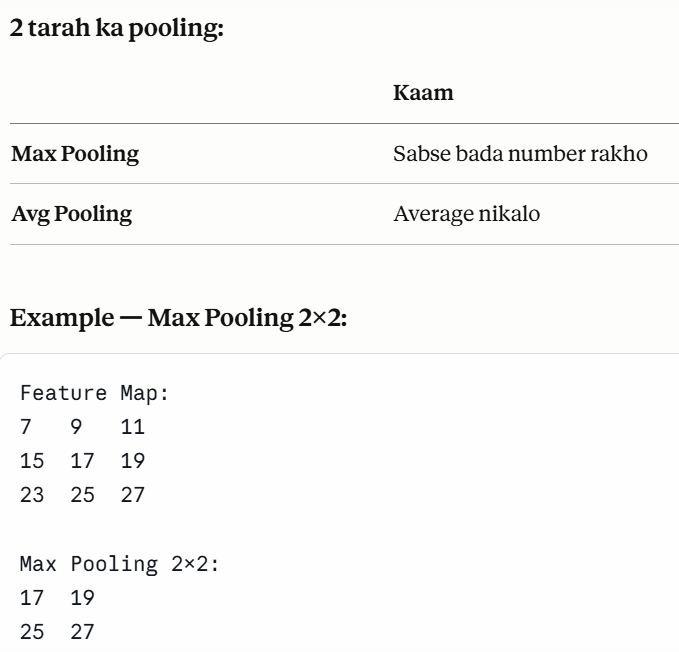

# Stride aur Padding kya hota hai?
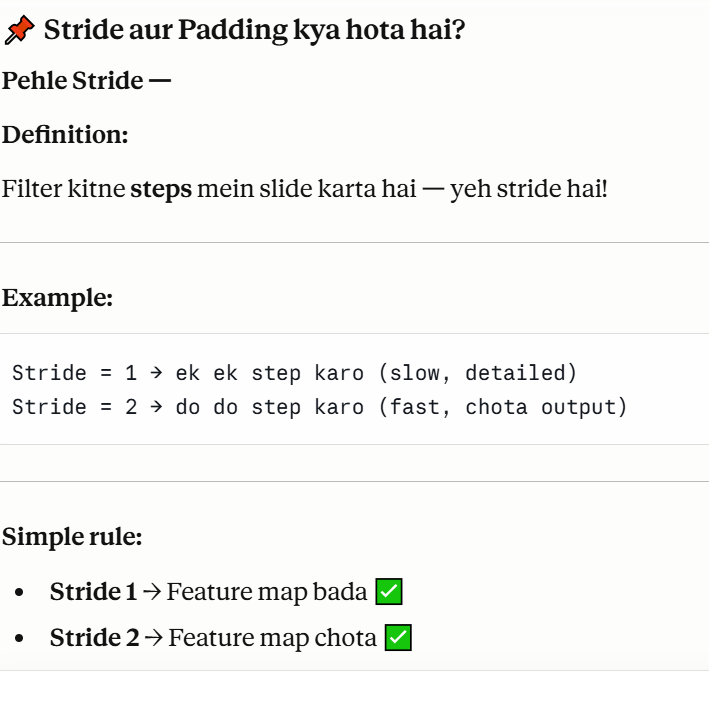

# Padding
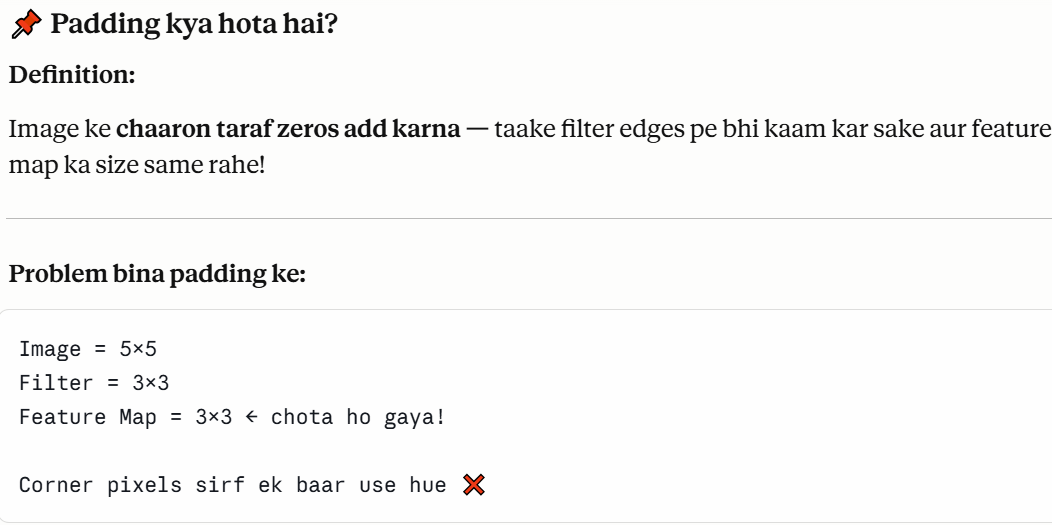
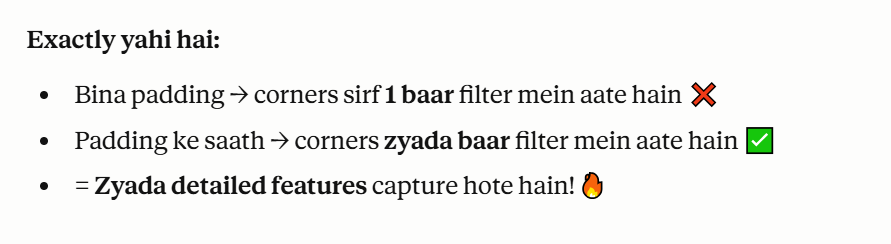

#  CNN Architecture kya hoti hai?
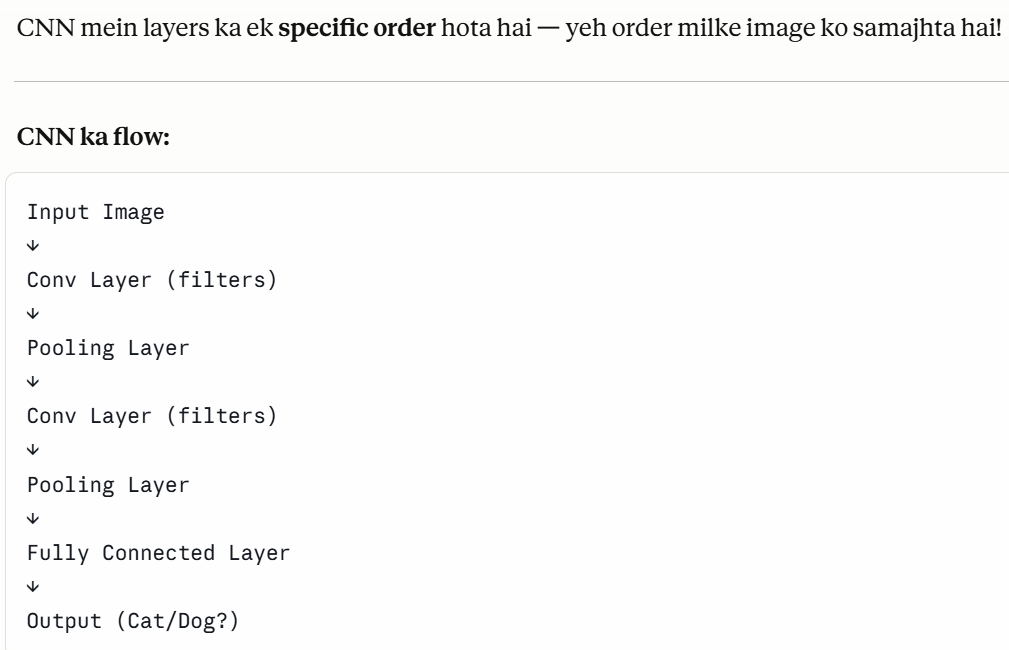
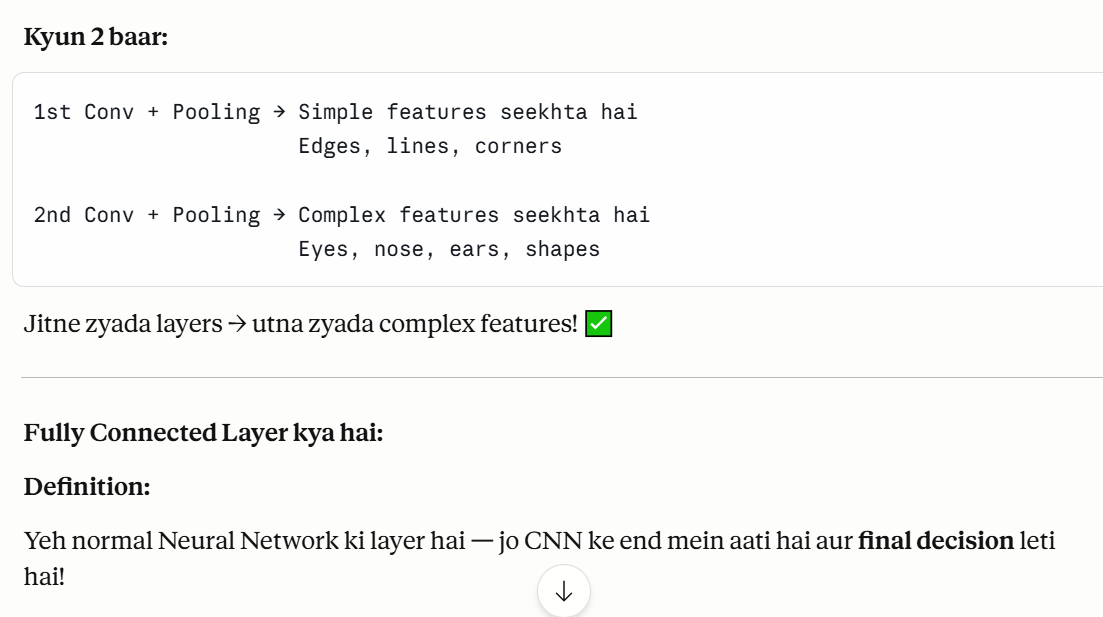
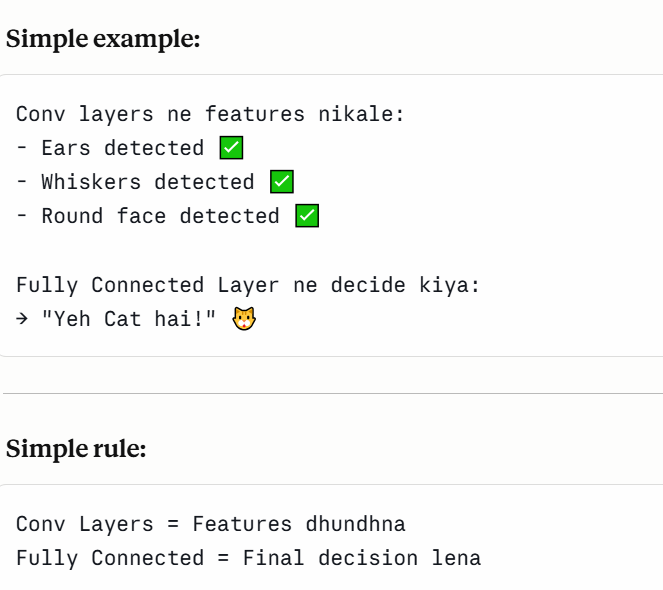
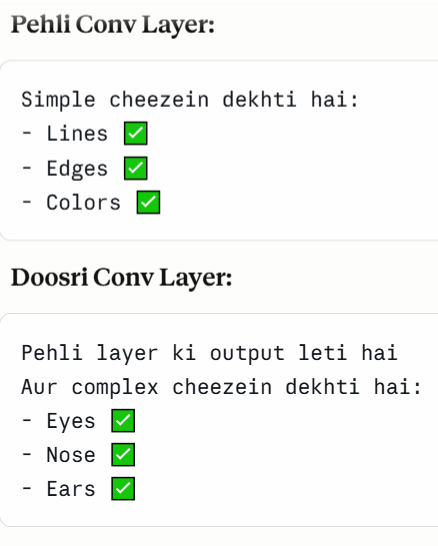
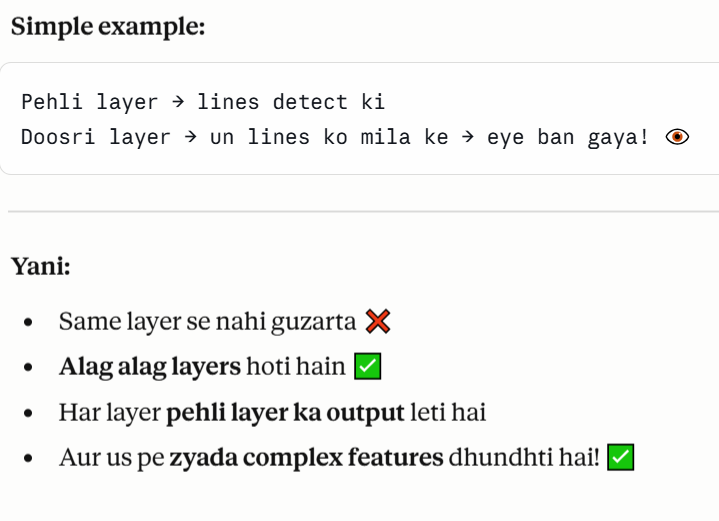

# 📌 Why CNN images ke liye better hai
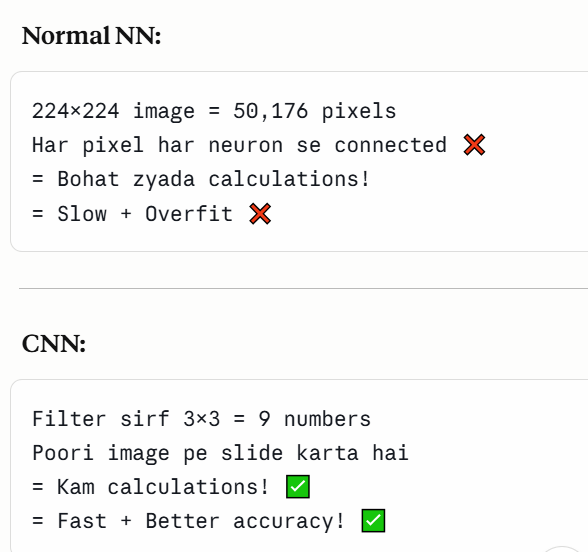
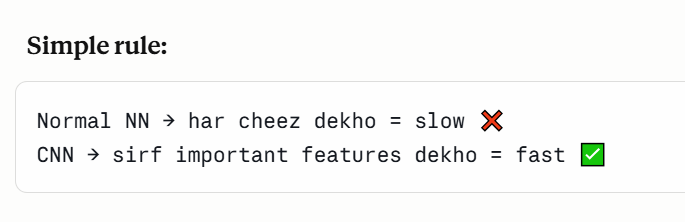

# MNIST kya hai
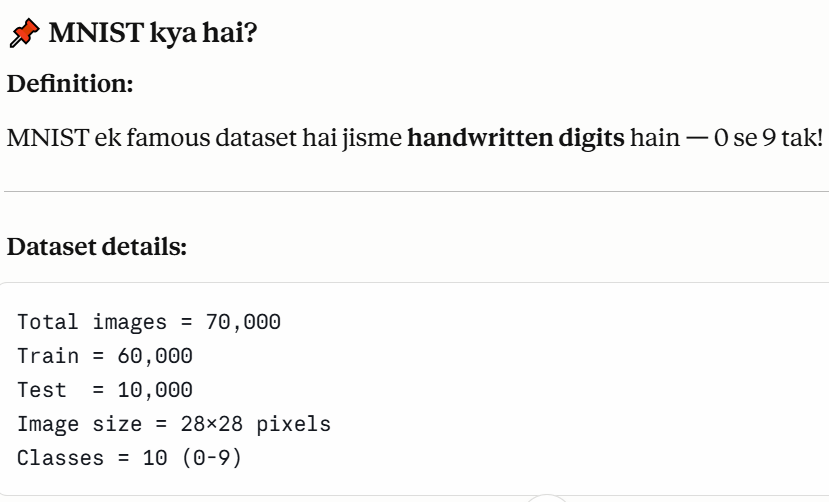

In [ ]:
pip install torchvision

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# Transform — image ko tensor banao aur normalize karo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Train data
train_data = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# Test data
test_data = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

print(f"Train: {len(train_data)}")
print(f"Test:  {len(test_data)}")

100%|██████████| 9.91M/9.91M [01:34<00:00, 104kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 123kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 347kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 818kB/s]


Train: 60000
Test:  10000


In [3]:
train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=64, 
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 938
Test batches:  157


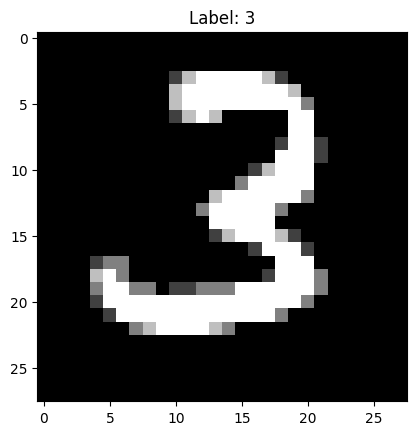

In [6]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0]}")
plt.show()

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Conv Layer 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        # Conv Layer 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Fully Connected
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Ready to train!")

Ready to train!


In [9]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    
    for images, labels in train_loader:
        # Forward pass
        output = model(images)
        loss = loss_fn(output, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1: Loss = 0.1529
Epoch 2: Loss = 0.0457
Epoch 3: Loss = 0.0302
Epoch 4: Loss = 0.0212
Epoch 5: Loss = 0.0169
Training Complete!


In [10]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.13%


In [16]:
from PIL import Image
import torchvision.transforms as transforms
import torch

# Apni image load karo
img = Image.open(r"C:\Users\PMLS\Downloads\thrrrr.jpg").convert('L')  # Grayscale

# Transform
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Transform apply karo
img_tensor = transform(img).unsqueeze(0)

# Predict karo
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

Predicted Digit: 4


In [18]:
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import torch

img = Image.open(r"c:\Users\PMLS\Downloads\oooon.jpg").convert('L')

# Image invert karo
img = ImageOps.invert(img)

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

img_tensor = transform(img).unsqueeze(0)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Predicted Digit: {predicted.item()}")

Predicted Digit: 5
